In [526]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadr import read_r
import numpy as np
import re

# Load the data
ling_data = pd.read_csv('../data/lingData.txt', sep='\\s+')
ling_location = pd.read_csv('../data/lingLocation.txt', sep='\\s+')

# ling_data has a column for each question, and ling_location has a column
# for each question x answer.  Sorry the columns in ling_location are not usefully named,
# but it's not too tricky to figure out which is which.
# Note that you still need to clean this data (check for NA's, missing location data, etc.)

# Load the question_data which contains quest.mat, quest.use, ans.---
# This has the actual text of the questions
question_data = read_r('../data/question_data.RData')

## Clean the pop/state data

In [527]:
# df_state_pop = pd.read_csv(
#     'state_population.csv',
#     usecols=['state', 'population'],
#     thousands=','
# )


In [528]:
# df_state_pop = df_state_pop.dropna()

In [529]:
# df_state_pop["state"] = df_state_pop["state"].str.strip()

In [530]:
# print(df_state_pop.dtypes)

In [531]:
# df_state_pop.to_csv('state_population.csv', index=False)

In [532]:
# df_state_pop = df_state_pop[['state', 'population']]

In [533]:
# Inspect column names
# This has the individual answer data, catagorical
print(ling_data.columns)
# And this has the binned/grouped answer data by lat/long and turned into binary
print(ling_location.columns)

# Load state geometries
state_df = gpd.read_file('../data/shapefiles')
state_df = state_df[state_df['iso_a2'] == 'US']  # Filter to only US


Index(['ID', 'CITY', 'STATE', 'ZIP', 'Q050', 'Q051', 'Q052', 'Q053', 'Q054',
       'Q055', 'Q056', 'Q057', 'Q058', 'Q059', 'Q060', 'Q061', 'Q062', 'Q063',
       'Q064', 'Q065', 'Q066', 'Q067', 'Q068', 'Q069', 'Q070', 'Q071', 'Q072',
       'Q073', 'Q074', 'Q075', 'Q076', 'Q077', 'Q078', 'Q079', 'Q080', 'Q081',
       'Q082', 'Q083', 'Q084', 'Q085', 'Q086', 'Q087', 'Q088', 'Q089', 'Q090',
       'Q091', 'Q092', 'Q093', 'Q094', 'Q095', 'Q096', 'Q097', 'Q098', 'Q099',
       'Q100', 'Q101', 'Q102', 'Q103', 'Q104', 'Q105', 'Q106', 'Q107', 'Q109',
       'Q110', 'Q111', 'Q115', 'Q117', 'Q118', 'Q119', 'Q120', 'Q121', 'lat',
       'long'],
      dtype='str')
Index(['Number of people in cell', 'Latitude', 'Longitude', 'V4', 'V5', 'V6',
       'V7', 'V8', 'V9', 'V10',
       ...
       'V462', 'V463', 'V464', 'V465', 'V466', 'V467', 'V468', 'V469', 'V470',
       'V471'],
      dtype='str', length=471)


## Cleaning exploration

In [534]:
print(ling_data.shape)
ling_data.info()   # dtypes and non-null counts per column
ling_data.head()

(47471, 73)
<class 'pandas.DataFrame'>
RangeIndex: 47471 entries, 0 to 47470
Data columns (total 73 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      47471 non-null  int64  
 1   CITY    46931 non-null  str    
 2   STATE   47468 non-null  str    
 3   ZIP     47471 non-null  int64  
 4   Q050    47471 non-null  int64  
 5   Q051    47471 non-null  int64  
 6   Q052    47471 non-null  int64  
 7   Q053    47471 non-null  int64  
 8   Q054    47471 non-null  int64  
 9   Q055    47471 non-null  int64  
 10  Q056    47471 non-null  int64  
 11  Q057    47471 non-null  int64  
 12  Q058    47471 non-null  int64  
 13  Q059    47471 non-null  int64  
 14  Q060    47471 non-null  int64  
 15  Q061    47471 non-null  int64  
 16  Q062    47471 non-null  int64  
 17  Q063    47471 non-null  int64  
 18  Q064    47471 non-null  int64  
 19  Q065    47471 non-null  int64  
 20  Q066    47471 non-null  int64  
 21  Q067    47471 non-null  int64  
 2

,ID,CITY,STATE,ZIP,Q050,Q051,Q052,Q053,Q054,Q055,...,Q110,Q111,Q115,Q117,Q118,Q119,Q120,Q121,lat,long
0,1,Boise,ID,83704,4,1,3,2,3,1,...,8,2,1,6,7,3,2,3,43.631230,-116.287161
1,2,Pittsfield,MA,1201,4,2,3,2,2,2,...,8,2,1,1,7,1,1,3,42.453840,-73.254003
2,3,Burlington,VT,5401,4,1,2,2,2,2,...,4,2,1,4,7,1,2,1,44.484038,-73.221265
3,4,Easton,PA,18042,7,1,1,2,2,2,...,8,1,1,3,7,1,2,1,40.681798,-75.220820
4,5,Bedford,MA,1730,8,2,3,1,2,2,...,8,3,1,5,8,1,1,1,42.496679,-71.275046


In [535]:
print(ling_data.isna().sum()[lambda s: s > 0])

CITY      540
STATE       3
lat      1020
long     1020
dtype: int64


In [536]:
ling_data = ling_data[(~ling_data["lat"].isna()) | (~ling_data["long"].isna())]

In [537]:
print(ling_data.isna().sum()[lambda s: s > 0])

CITY     523
STATE      3
dtype: int64


In [538]:
# there also should not be any zeros right as asnwers
q_cols = [c for c in ling_data.columns if c.startswith('Q')]
print((ling_data[q_cols] == 0).sum().sort_values(ascending=False))

Q092    3782
Q083    2898
Q071    2481
Q095    2298
Q077    2187
        ... 
Q056    1255
Q063    1255
Q054    1255
Q052    1240
Q050    1237
Length: 67, dtype: int64


In [539]:
# or like -1?
q_cols = [c for c in ling_data.columns if c.startswith('Q')]
print((ling_data[q_cols] == -1).sum().sort_values(ascending=False))

Q050    0
Q100    0
Q086    0
Q087    0
Q088    0
       ..
Q078    0
Q079    0
Q080    0
Q081    0
Q121    0
Length: 67, dtype: int64


In [540]:
n_skipped = (ling_data[q_cols] == 0).sum(axis=1)
print(n_skipped.value_counts().sort_index())

0     39218
1      2437
2      1382
3       770
4       460
      ...  
63        6
64       19
65       19
66       32
67     1015
Name: count, Length: 68, dtype: int64


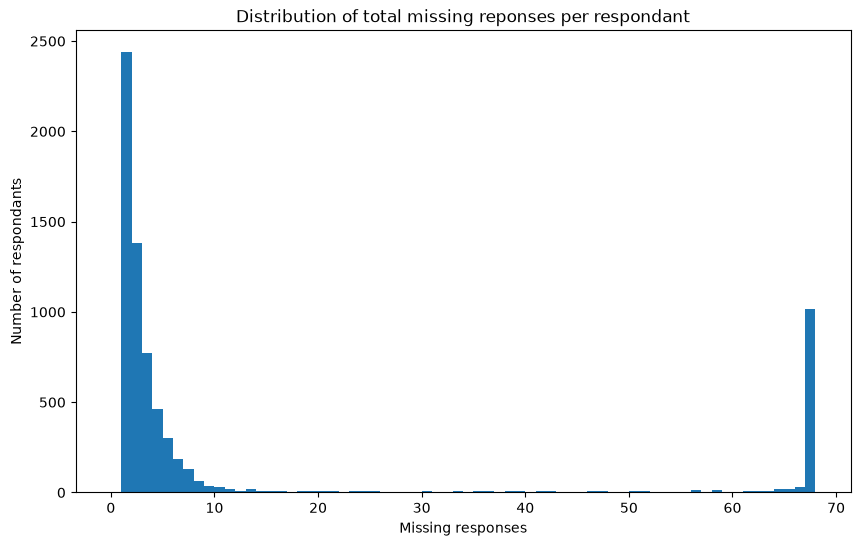

In [541]:
# since each row is one respondant how many did each person miss?
n_skipped = (ling_data[q_cols] == 0).sum(axis=1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(n_skipped[n_skipped>0], bins=range(0, 69))
ax.set_xlabel('Missing responses')
ax.set_ylabel('Number of respondants')
ax.set_title("Distribution of total missing reponses per respondant")
plt.show()

In [542]:
# ok now looking at the specific value ranges
for c in q_cols:
    n_opts = len(question_data[f'ans.{int(c[1:])}'])
    bad = (ling_data[c] > n_opts).sum()
    if bad:
        print(c, bad, 'invalid codes')

In [543]:
print(ling_data['lat'].describe(), ling_data['long'].describe())  

count    46451.000000
mean        39.445319
std          4.709227
min         19.226749
25%         37.322936
50%         40.335023
75%         42.238087
max         71.299525
Name: lat, dtype: float64 count    46451.000000
mean       -90.481846
std         15.700260
min       -161.423934
25%        -96.164545
50%        -87.631261
75%        -77.278880
max        -67.003914
Name: long, dtype: float64


In [544]:
print(ling_data['ID'].duplicated().sum())
print(ling_data.drop(columns='ID').duplicated().sum())

0
396


## Question specific cleaning

In [545]:
my_qs = ['Q094', 'Q111']   # add your other questions here

In [546]:
ak_hi = ling_data[ling_data['STATE'].isin(['AK', 'HI'])]

print(ak_hi['STATE'].value_counts())        # total respondents per state
print((ak_hi[my_qs] != 0).groupby(ak_hi['STATE']).sum())   # answered, per question

STATE
HI    107
AK     98
Name: count, dtype: int64
       Q094  Q111
STATE            
AK       94    94
HI      103   103


In [547]:

# Remove Alaska and Hawaii
ling_data = ling_data[~ling_data['STATE'].isin(['AK', 'HI'])]
state_df = state_df[~state_df['postal'].isin(['AK', 'HI'])]

In [548]:
question_numbers = question_data['quest.use']['qnum'].astype(int).tolist()
# Verified that we only have question_number 50-121 here

In [549]:
quest_use = question_data['quest.use']

with open('questions_answers.txt', 'w') as f:
    for _, row in quest_use.iterrows():
        q = int(row['qnum'])
        text = re.sub(r'<[^>]+>', '', row['quest']) # get rid of html tags like mentioned
        print(f"\nQ{q}: {text}", file=f)

        ans = question_data[f'ans.{q}']
        for i, a in enumerate(ans.itertuples(), start=1):
            print(f"   {i} ({a._2}) {a.ans.strip():<40} {a.per:5.1f}%", file=f)

In [550]:
# Define the map theme
def my_map_theme():
    plt.axis('off')

def plot_on_map(data_to_plot, title):
    plt.figure(figsize=(10, 8))
    ax = sns.scatterplot(data=data_to_plot, x='long', y='lat', hue='ans', s=10, alpha=0.5)
    state_gdf = gpd.GeoDataFrame(state_df)
    state_gdf.boundary.plot(ax=plt.gca(), color='black')
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), title=None)
    my_map_theme()
    plt.title(title)
    plt.show()

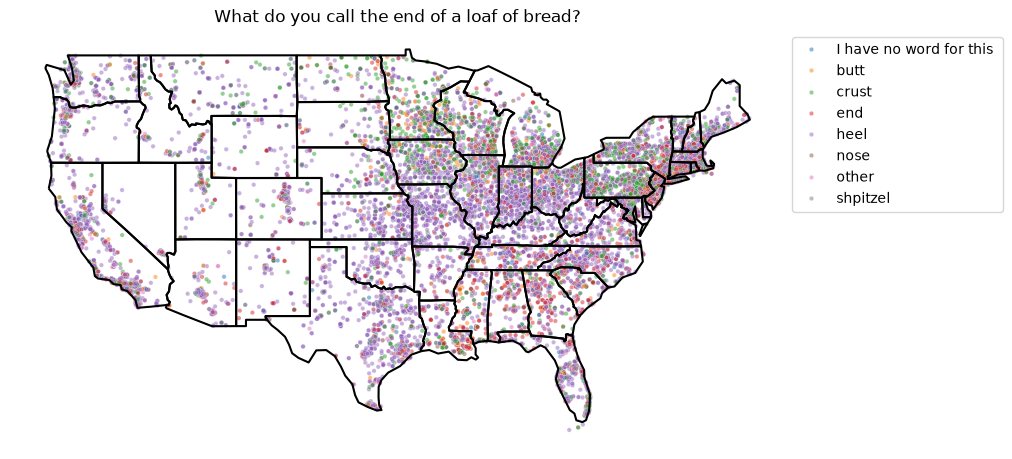

In [551]:
last_slice_bread = ling_data[(ling_data['Q111'].between(1,8)) & (ling_data['long'] > -125)]
answers_q111 = question_data['ans.111']

# Prepare to join
answers_q111['Q111'] = (answers_q111.index + 1).astype(str)
last_slice_bread['Q111'] = last_slice_bread['Q111'].astype(str)
last_slice_bread = last_slice_bread.merge(answers_q111, on='Q111', how='inner')
# remove unused categories
last_slice_bread['ans'] = last_slice_bread['ans'].cat.remove_unused_categories()

# Plot
plot_on_map(last_slice_bread, "What do you call the end of a loaf of bread?")

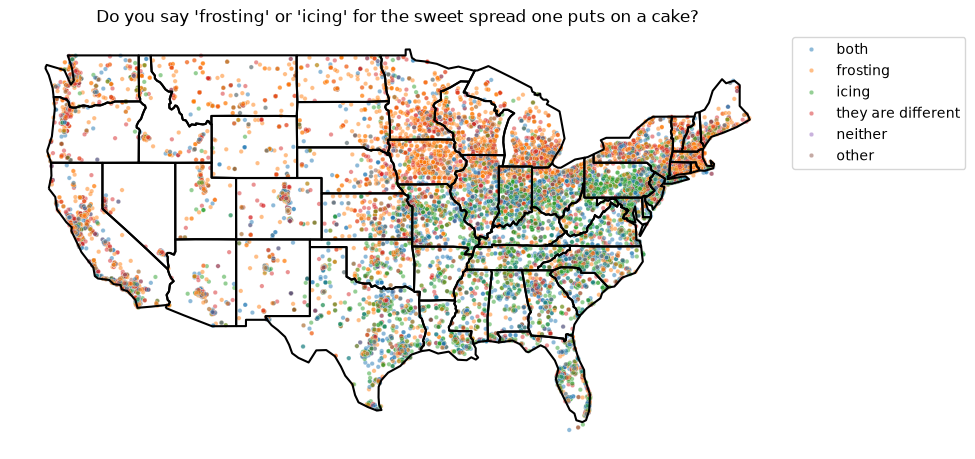

In [552]:
icing_frosting = ling_data[(ling_data['Q094'].between(1,6)) & (ling_data['long'] > -125)]
answers_q094 = question_data['ans.94']

# Prepare to join
answers_q094['Q094'] = (answers_q094.index + 1).astype(str)
icing_frosting['Q094'] = icing_frosting['Q094'].astype(str)
icing_frosting = icing_frosting.merge(answers_q094, on='Q094', how='inner')
# remove unused categories
icing_frosting['ans'] = icing_frosting['ans'].cat.remove_unused_categories()

# rename the long ones so they plot better
icing_frosting['ans'] = icing_frosting['ans'].cat.rename_categories({
    'icing is thinner than frosting, white, and/or made of powdered sugar and milk or lemon juice ': 'they are different',
})

plot_on_map(icing_frosting, "Do you say 'frosting' or 'icing' for the sweet spread one puts on a cake?")

## Explore Dimension Reduction

In [553]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.linalg import svd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [554]:
# jsut make a file to visualize the one hot encoded cols relative to the wuestions and answers
q_cols = [c for c in ling_data.columns if c.startswith("Q")]
quest = question_data["quest.mat"].set_index("qnum")["quest"]

col = 4
with open("ling_location_columns.txt", "w") as f:
    for c in q_cols:
        q = int(c[1:])
        ans = question_data[f"ans.{q}"]
        for i, a in enumerate(ans["ans"].astype(str).str.strip(), start=1):
            f.write(f"V{col}\t{c}\t{i}\t{a}\t{quest[q]}\n")
            col += 1

print("last column:", f"V{col - 1}")

last column: V471


In [555]:
ling_location.columns

Index(['Number of people in cell', 'Latitude', 'Longitude', 'V4', 'V5', 'V6',
       'V7', 'V8', 'V9', 'V10',
       ...
       'V462', 'V463', 'V464', 'V465', 'V466', 'V467', 'V468', 'V469', 'V470',
       'V471'],
      dtype='str', length=471)

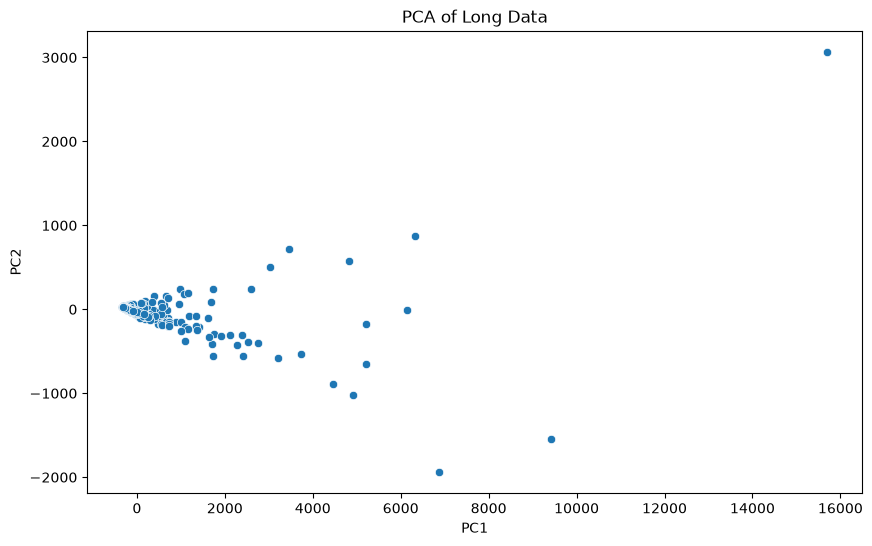

In [556]:
# PCA using sklearn
pca = PCA(n_components=0.95)  # retain 99% variance
X_pca = pca.fit_transform(ling_location)

ling_shares = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
# brca_scores['Subtype'] = Y['BRCA_Subtype_PAM50']  # Assuming Y has the subtype information

# Plot PC scores
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ling_shares, x='PC1', y='PC2')
plt.title('PCA of Long Data')
plt.show()

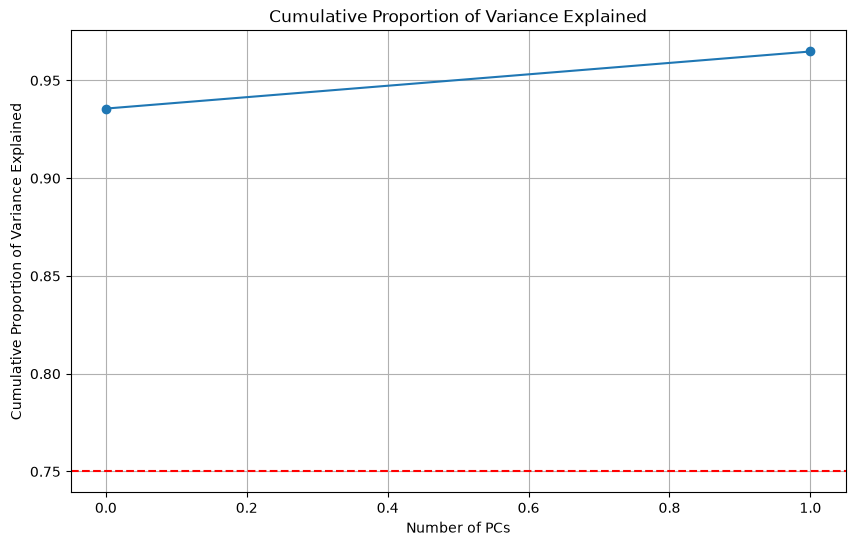

In [557]:
cum_var_explained = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative variance explained
plt.figure(figsize=(10, 6))
plt.plot(cum_var_explained, marker='o')
plt.axhline(0.75, color='red', linestyle='--')
plt.title('Cumulative Proportion of Variance Explained')
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative Proportion of Variance Explained')
plt.grid()
plt.show()

In [558]:
# # How many PC's would you need to explain 75% of the variance?
n_pcs = np.argmax(cum_var_explained >= 0.95) + 1
print(f'Number of PCs to explain 75% of variance: {n_pcs}')

Number of PCs to explain 75% of variance: 2


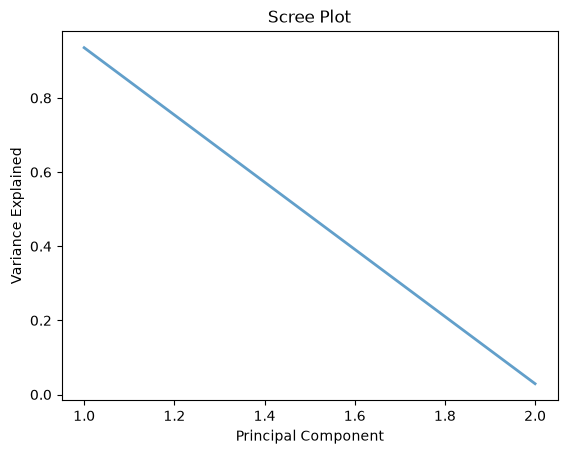

In [559]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, '-', linewidth=2, alpha=0.7)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

In [560]:
print(np.corrcoef(X_pca[:, 0], ling_location["Number of people in cell"])[0, 1])

0.9998645200721729


Now try scaling the vectors by number of peaople at lat, long

In [561]:
answer_cols = ling_location.columns[3:]
n = ling_location["Number of people in cell"]

ling_location = ling_location[n > 0]
ling_location_prop = ling_location[answer_cols].div(ling_location["Number of people in cell"], axis=0)

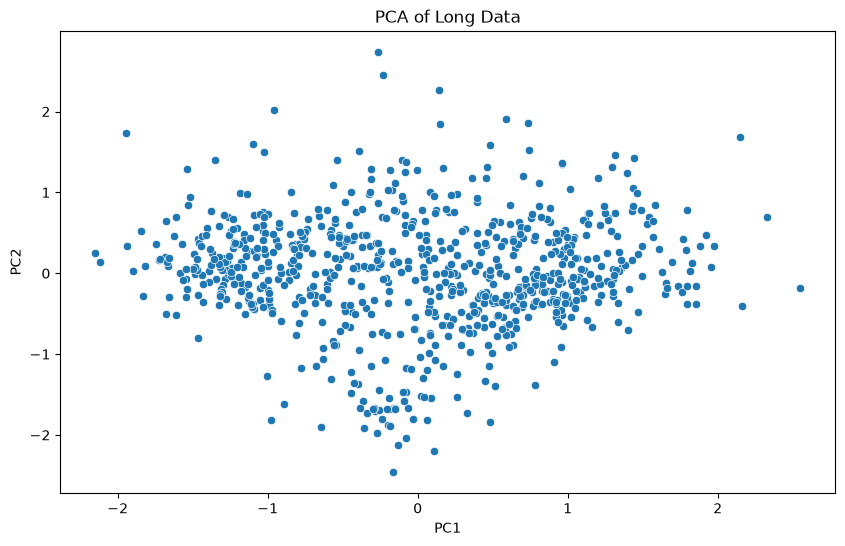

In [562]:
# PCA using sklearn
pca = PCA(n_components=0.95)  # retain 95% variance
X_pca = pca.fit_transform(ling_location_prop)

ling_shares = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
# brca_scores['Subtype'] = Y['BRCA_Subtype_PAM50']  # Assuming Y has the subtype information

# Plot PC scores
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ling_shares, x='PC1', y='PC2')
plt.title('PCA of Long Data')
plt.show()

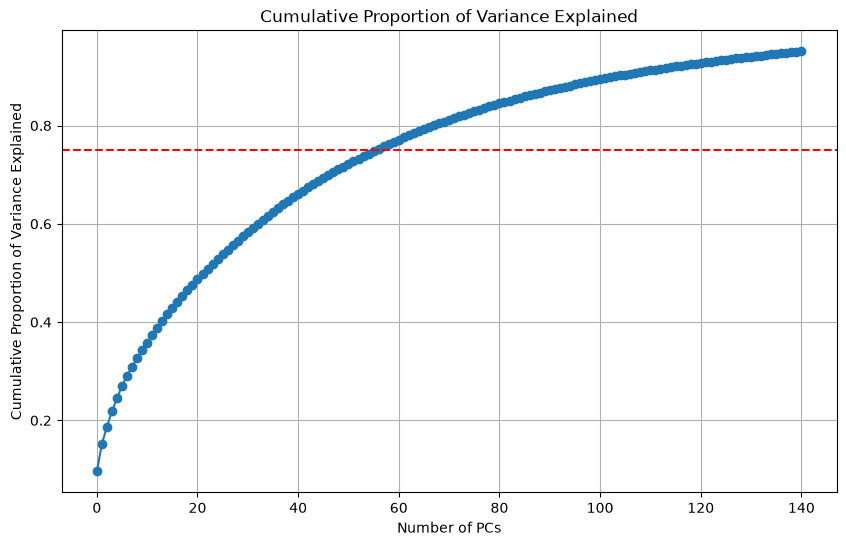

In [563]:
cum_var_explained = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative variance explained
plt.figure(figsize=(10, 6))
plt.plot(cum_var_explained, marker='o')
plt.axhline(0.75, color='red', linestyle='--')
plt.title('Cumulative Proportion of Variance Explained')
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative Proportion of Variance Explained')
plt.grid()
plt.show()

In [564]:
# # How many PC's would you need to explain 75% of the variance?
n_pcs = np.argmax(cum_var_explained >= 0.75) + 1
print(f'Number of PCs to explain 75% of variance: {n_pcs}')

Number of PCs to explain 75% of variance: 57


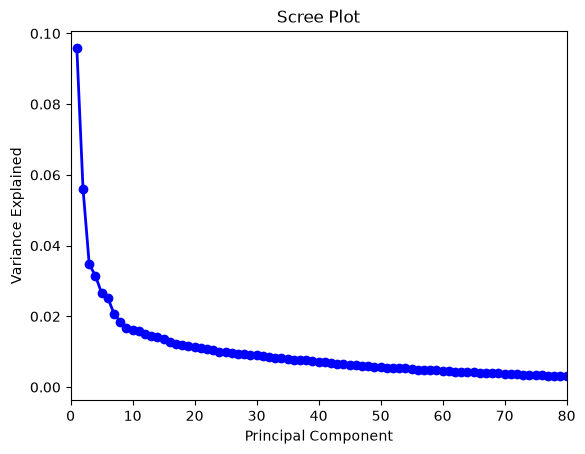

In [565]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xlim(0, 80)
plt.show()

Text(0.5, 1.0, 'PC1 by location')

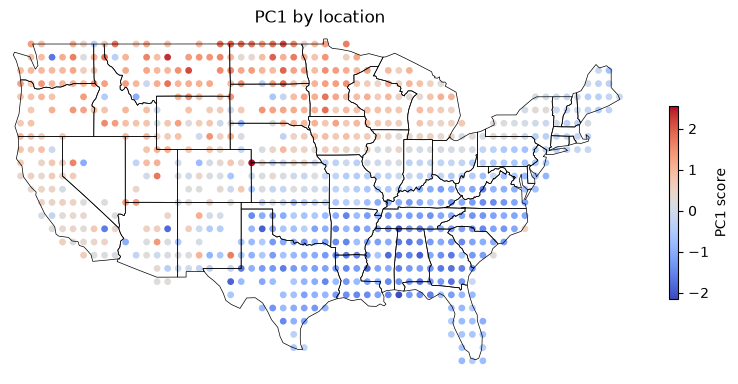

In [566]:
fig, ax = plt.subplots(figsize=(10, 5))
state_df.boundary.plot(ax=ax, color="black", linewidth=0.5)
sc = ax.scatter(ling_location["Longitude"], ling_location["Latitude"],
                c=X_pca[:, 0], cmap="coolwarm", s=15)
fig.colorbar(sc, ax=ax, shrink=0.5, label="PC1 score")
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis("off")
ax.set_title("PC1 by location")

Text(0.5, 1.0, 'PC2 by location')

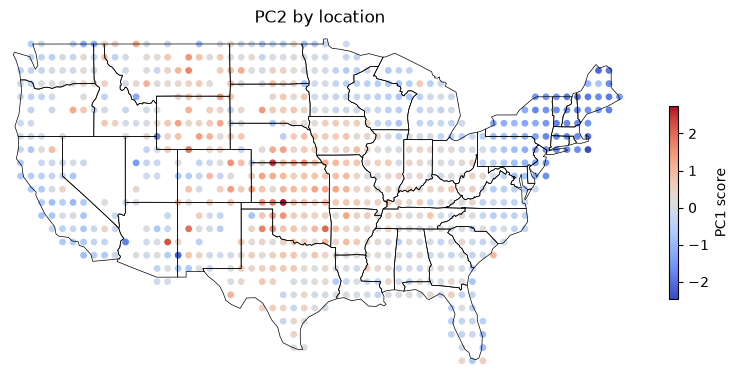

In [567]:
fig, ax = plt.subplots(figsize=(10, 5))
state_df.boundary.plot(ax=ax, color="black", linewidth=0.5)
sc = ax.scatter(ling_location["Longitude"], ling_location["Latitude"],
                c=X_pca[:, 1], cmap="coolwarm", s=15)
fig.colorbar(sc, ax=ax, shrink=0.5, label="PC1 score")
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis("off")
ax.set_title("PC2 by location")

Text(0.5, 1.0, 'PC3 by location')

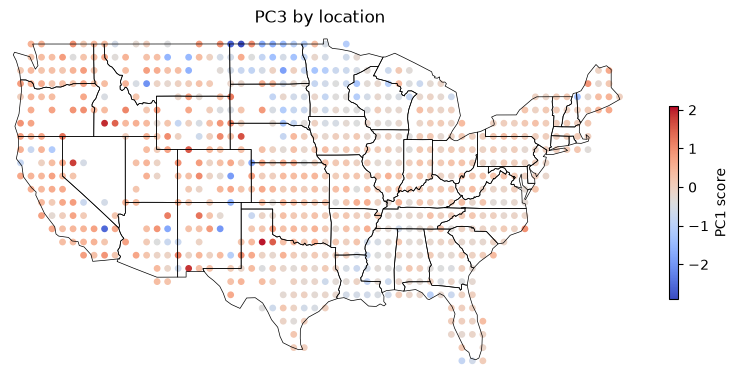

In [568]:
fig, ax = plt.subplots(figsize=(10, 5))
state_df.boundary.plot(ax=ax, color="black", linewidth=0.5)
sc = ax.scatter(ling_location["Longitude"], ling_location["Latitude"],
                c=X_pca[:, 2], cmap="coolwarm", s=15)
fig.colorbar(sc, ax=ax, shrink=0.5, label="PC1 score")
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis("off")
ax.set_title("PC3 by location")

## Now walking through from the book

In [569]:
answer_cols = ling_location.columns[3:]

X = ling_location[answer_cols].div(ling_location["Number of people in cell"], axis=0)

In [570]:
# Centered (using mean here, should try without)
X_centered = X - X.mean()
# X_centered = X - X.median()
# X_centered = X_centered / X.std()

In [571]:
U, d, V = np.linalg.svd(X_centered, full_matrices=False)

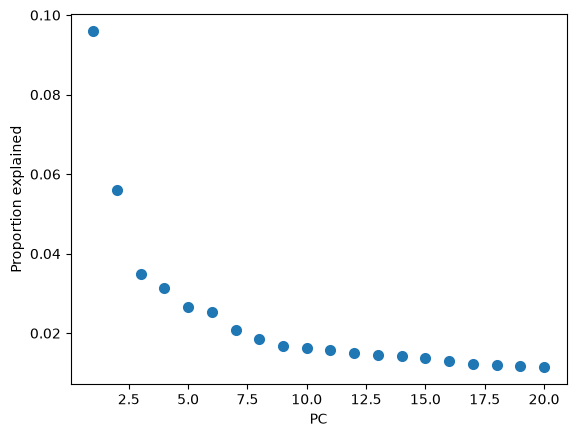

In [572]:
prop_var = d**2 / np.sum(d**2)
plt.scatter(x=np.arange(1, 21), y=prop_var[:20], marker='o', linewidth=2)
plt.xlabel("PC")
plt.ylabel("Proportion explained")
plt.show()

In [573]:
pc_scores = pd.DataFrame(X_centered.values @ V.T[:, :3], columns=["PC1", "PC2", "PC3"])
pc_scores["lat"] = ling_location["Latitude"].values
pc_scores["long"] = ling_location["Longitude"].values

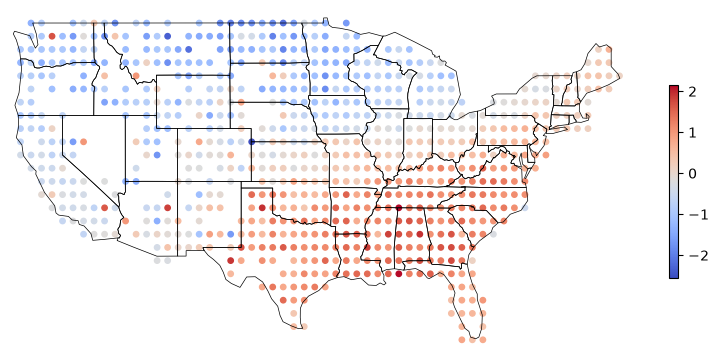

In [574]:
fig, ax = plt.subplots(figsize=(10, 5))
state_df.boundary.plot(ax=ax, color="black", linewidth=0.5)
sc = ax.scatter(pc_scores["long"], pc_scores["lat"], c=pc_scores["PC1"], cmap="coolwarm", s=15)
fig.colorbar(sc, ax=ax, shrink=0.5)
ax.set_xlim(-125, -66); ax.set_ylim(24, 50); ax.axis("off")
plt.show()

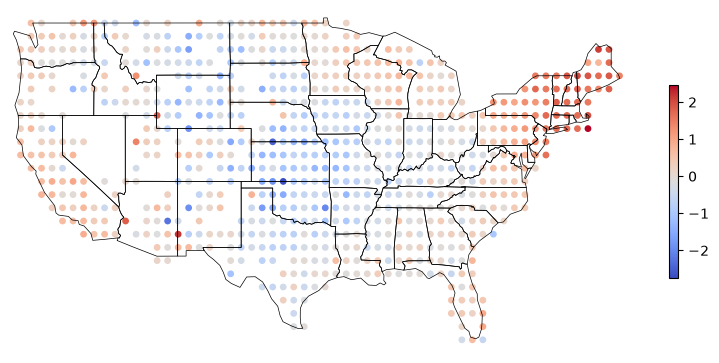

In [575]:
fig, ax = plt.subplots(figsize=(10, 5))
state_df.boundary.plot(ax=ax, color="black", linewidth=0.5)
sc = ax.scatter(pc_scores["long"], pc_scores["lat"], c=pc_scores["PC2"], cmap="coolwarm", s=15)
fig.colorbar(sc, ax=ax, shrink=0.5)
ax.set_xlim(-125, -66); ax.set_ylim(24, 50); ax.axis("off")
plt.show()

In [579]:
col_names = pd.read_csv("ling_location_columns.txt", sep="\t", header=None,
                        names=["col", "q", "code", "answer", "question"])
loadings = col_names.assign(pc1=V[0])
loadings.reindex(loadings["pc1"].abs().sort_values(ascending=False).index).head(10)

,col,q,code,answer,question,pc1
197,V201,Q076,1,kitty-corner,What term do you use to refer to something tha...,-0.252696
384,V388,Q105,2,pop,What is your generic term for a sweetened carb...,-0.241209
8,V12,Q050,9,y'all,What word(s) do you use to address a group of ...,0.207595
200,V204,Q076,4,catty-corner,What term do you use to refer to something tha...,0.204814
375,V379,Q103,4,water fountain,What do you call the thing from which you migh...,0.176686
343,V347,Q099,1,frontage road,Which of these terms do you prefer for the sma...,-0.172669
374,V378,Q103,3,drinking fountain,What do you call the thing from which you migh...,-0.170118
3,V7,Q050,4,you guys,What word(s) do you use to address a group of ...,-0.169880
385,V389,Q105,3,coke,What is your generic term for a sweetened carb...,0.167543
313,V317,Q094,1,frosting,Do you say 'frosting' or 'icing' for the sweet...,-0.160760


In [584]:
loadings["sq_pc1"] = loadings["pc1"] ** 2
q_load = loadings.groupby(["q", "question"])["sq_pc1"].sum().sort_values(ascending=False)
q_load.head(50)

q     question                                                                                                                                                                                                                                                  
Q076  What term do you use to refer to something that is across both streets from you at an intersection (or diagonally across from you in general)?                                                                                                                0.106361
Q105  What is your generic term for a sweetened carbonated beverage?                                                                                                                                                                                                0.088527
Q050  What word(s) do you use to address a group of two or more people?                                                                                                                                      

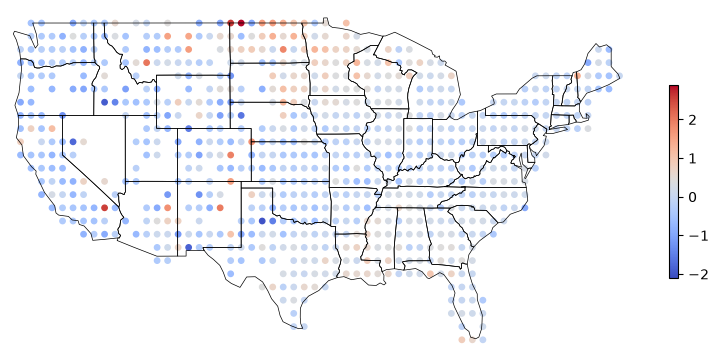

In [577]:
fig, ax = plt.subplots(figsize=(10, 5))
state_df.boundary.plot(ax=ax, color="black", linewidth=0.5)
sc = ax.scatter(pc_scores["long"], pc_scores["lat"], c=pc_scores["PC3"], cmap="coolwarm", s=15)
fig.colorbar(sc, ax=ax, shrink=0.5)
ax.set_xlim(-125, -66); ax.set_ylim(24, 50); ax.axis("off")
plt.show()

## Explore Clustering

In [578]:
# here